In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Hypotheses

**Null Hypothesis (H₀):** Blue Jays pitchers show no significant change in velocity, spin rate, or command (release point deviation) as pitch count increases within a game — i.e., game phase (Early / Mid / Late) has no effect on these mechanics.

**Alternative Hypothesis (H₁):** Blue Jays pitchers exhibit measurable fatigue as pitch count increases — specifically, velocity and/or spin rate decrease, and command worsens (greater release point deviation) in later game phases compared to earlier phases.

In [2]:

general_df = pd.read_csv('dataset_cleaned.csv')
general_df

,Unnamed: 0,game_year,game_date,player_name,pitcher,batter,balls,strikes,inning,inning_topbot,...,if_fielding_alignment,of_fielding_alignment,spin_axis,delta_home_win_exp,delta_run_exp,bat_speed,swing_length,cum_pitch_count,game_phase,score_diff
0,0,2025,2025-10-04,"Domínguez, Seranthony",622554,683011,0,0,7,Top,...,Standard,Standard,217.0,0.000,-0.040,NaN,NaN,1,Late,-1
1,1,2025,2025-10-04,"Domínguez, Seranthony",622554,683011,0,1,7,Top,...,Standard,Standard,208.0,0.000,0.019,NaN,NaN,2,Late,-1
2,2,2025,2025-10-04,"Domínguez, Seranthony",622554,683011,1,1,7,Top,...,Standard,Standard,93.0,0.000,0.063,NaN,NaN,3,Late,-1
3,3,2025,2025-10-04,"Domínguez, Seranthony",622554,683011,2,1,7,Top,...,Standard,Standard,209.0,0.000,-0.075,69.1,5.9,4,Late,-1
4,4,2025,2025-10-04,"Domínguez, Seranthony",622554,683011,2,2,7,Top,...,Standard,Standard,217.0,0.055,-0.221,NaN,NaN,5,Late,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2617,2617,2025,2025-11-01,"Yesavage, Trey",702056,571970,0,0,8,Top,...,Infield shade,Standard,213.0,0.000,-0.039,NaN,NaN,17,Late,-2
2618,2618,2025,2025-11-01,"Yesavage, Trey",702056,571970,0,1,8,Top,...,Infield shade,Standard,211.0,0.000,0.028,NaN,NaN,18,Late,-2
2619,2619,2025,2025-11-01,"Yesavage, Trey",702056,571970,1,1,8,Top,...,Infield shade,Standard,219.0,-0.099,1.593,75.2,7.4,19,Late,-2
2620,2620,2025,2025-11-01,"Yesavage, Trey",702056,606192,0,0,8,Top,...,Standard,Standard,199.0,0.000,-0.039,75.2,8.6,20,Late,-1


In [3]:
print(general_df.shape)
general_df['cum_pitch_count'].describe()

(2622, 89)


count    2622.000000
mean       26.181541
std        24.228103
min         1.000000
25%         7.000000
50%        16.000000
75%        43.000000
max       104.000000
Name: cum_pitch_count, dtype: float64

In [4]:
print('Number of games: ', general_df['game_pk'].nunique())
print('Number of pitchers: ', general_df['pitcher'].nunique())

Number of games:  18
Number of pitchers:  15


In [5]:
my_vars = ['release_speed', 'release_spin_rate', 'delta_run_exp', 'pitch_name', 'cum_pitch_count']
general_df[my_vars].isnull().sum()

release_speed        0
release_spin_rate    0
delta_run_exp        0
pitch_name           0
cum_pitch_count      0
dtype: int64

pitch_name
4-Seam Fastball    921
Slider             511
Split-Finger       338
Cutter             195
Knuckle Curve      143
Sinker             141
Curveball          132
Changeup           123
Sweeper            118
Name: count, dtype: int64


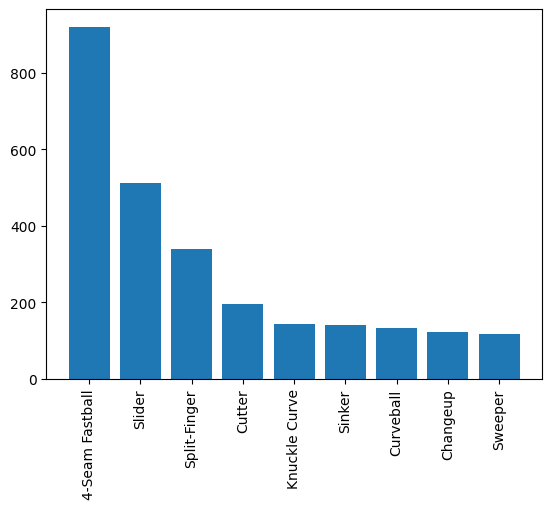

In [6]:
plt.bar(general_df['pitch_name'].value_counts().index, general_df['pitch_name'].value_counts().values)
plt.xticks(rotation=90)
print(general_df['pitch_name'].value_counts())

In [7]:
general_df['inning'].value_counts().sort_index()

inning
1     296
2     278
3     301
4     256
5     244
6     279
7     299
8     265
9     249
10     39
11     27
12     12
13      8
14     26
15     14
16     11
17     13
18      5
Name: count, dtype: int64

In [8]:
substitute = (general_df[general_df['inning'] >= 10].groupby('player_name').agg(
    min_inning=('inning', 'min'),
    max_inning=('inning', 'max'), 
    min_cum=('cum_pitch_count', 'min'), 
    max_cum=('cum_pitch_count', 'max'), 
    total_pitches=('cum_pitch_count', 'count')).sort_values('min_inning'))

substitute

,min_inning,max_inning,min_cum,max_cum,total_pitches
player_name,,,,,
"Domínguez, Seranthony",10,10,1,24,24
"Hoffman, Jeff",10,10,14,28,15
"Bieber, Shane",11,11,1,12,12
"Fisher, Braydon",11,12,1,19,19
"Lauer, Eric",12,16,1,67,67
"Little, Brendon",17,18,1,18,18


In [9]:
general_df.groupby('pitch_name')['release_speed'].mean().sort_values(ascending=False)

pitch_name
4-Seam Fastball    94.990662
Sinker             94.377305
Cutter             90.247179
Changeup           89.638211
Slider             87.239139
Knuckle Curve      86.526573
Split-Finger       84.606213
Sweeper            83.494915
Curveball          79.026515
Name: release_speed, dtype: float64

In [10]:
general_df[general_df['inning'] > 7].head()  

,Unnamed: 0,game_year,game_date,player_name,pitcher,batter,balls,strikes,inning,inning_topbot,...,if_fielding_alignment,of_fielding_alignment,spin_axis,delta_home_win_exp,delta_run_exp,bat_speed,swing_length,cum_pitch_count,game_phase,score_diff
80,80,2025,2025-10-04,"Hoffman, Jeff",656546,519317,0,0,9,Top,...,Standard,Standard,220.0,0.0,-0.039,NaN,NaN,1,Late,-9
81,81,2025,2025-10-04,"Hoffman, Jeff",656546,519317,0,1,9,Top,...,Standard,Standard,224.0,0.0,-0.220,74.1,8.5,2,Late,-9
82,82,2025,2025-10-04,"Hoffman, Jeff",656546,665862,0,0,9,Top,...,Infield shade,Standard,224.0,0.0,-0.039,72.9,7.8,3,Late,-9
83,83,2025,2025-10-04,"Hoffman, Jeff",656546,665862,0,1,9,Top,...,Infield shade,Standard,223.0,0.0,0.028,NaN,NaN,4,Late,-9
84,84,2025,2025-10-04,"Hoffman, Jeff",656546,665862,2,1,9,Top,...,Infield shade,Standard,96.0,0.0,-0.070,76.5,8.9,5,Late,-9


Takeaway:
- Blue Jays may have a lot of relievers
- cum_pitch_count --> Right skewed distribution 
- 4 Seam Fastball thrown most. Curveball thrown least

- Extra innings (inning 10+) will be dropped for Q1 analysis. 
  cum_pitch_count resets for each new pitcher, meaning a reliever 
  entering in inning 14 at pitch count 1 is indistinguishable from 
  a starter's pitch 1 in inning 1. Including extra innings would 
  confound the fatigue signal.

- All 9 pitch types pass the 90-observation threshold overall, but 
  sample sizes may become thin when split by individual pitcher. 
  Analysis will be done at the aggregate level first.

- The right-skewed cum_pitch_count distribution (mean=26, median=16, 
  max=104) suggests most pitchers are relievers throwing fewer than 
  43 pitches. The fatigue signal, if it exists, will be driven 
  primarily by the small number of starters reaching high pitch counts.